<a href="https://colab.research.google.com/github/aaryachauhan123/AI-ML-Learning/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

import matplotlib.pyplot as plt
import seaborn as sn



In [ ]:
df = pd.read_csv('/content/waste management.csv')

print(df.head())
print(df.isnull().sum())
df.fillna(df.mean(), inplace=True)
print(df.isnull().sum())



   waste_type  material_composition  recycling_potential  toxicity_level  \
0           3              0.198716             0.016588       81.011339   
1           1              0.005522             0.512093       86.707232   
2           3              0.815461             0.226496       91.324055   
3           3              0.706857             0.645173       51.134240   
4           1              0.729007             0.174366       50.151629   

   management_strategy  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  
waste_type              0
material_composition    0
recycling_potential     0
toxicity_level          0
management_strategy     0
dtype: int64
waste_type              0
material_composition    0
recycling_potential     0
toxicity_level          0
management_strategy     0
dtype: int64


In [ ]:
print(df.head().sum())

waste_type               11.000000
material_composition      2.455564
recycling_potential       1.574716
toxicity_level          360.328496
management_strategy       0.000000
dtype: float64


In [ ]:
df.shape

(100, 5)

In [ ]:
X=df[['waste_type', 'material_composition', 'recycling_potential', 'toxicity_level']]
y=df['management_strategy']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [ ]:
#set the number of neighbors
k=5
model=SVC(kernel='linear', C=1.0)
model.fit(X_train,y_train)


SVC(kernel='linear')

In [ ]:
y_pred=model.predict(X_test)
print(y_pred)

[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.95


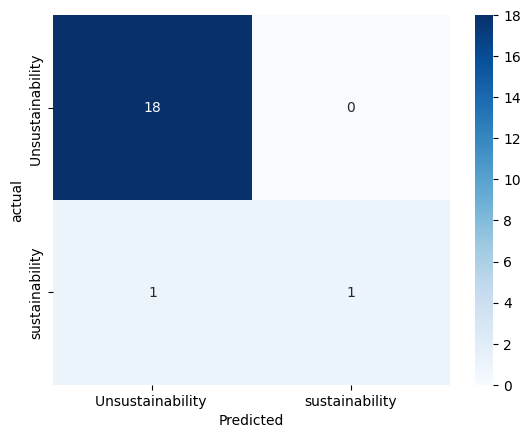

In [ ]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

#confution matrix

cm_result=sk_confusion_matrix(y_test,y_pred)
sn.heatmap(cm_result,annot=True,fmt='d',cmap='Blues',
           xticklabels=['Unsustainability ','sustainability'],
           yticklabels=['Unsustainability ','sustainability']
           )
plt.xlabel('Predicted')
plt.ylabel('actual')
plt.show()


getting report of prcision ,recall, and f1 score, support

In [ ]:
print(classification_report(y_test,y_pred,target_names=['Unsustainability','sustainability']))

                  precision    recall  f1-score   support

Unsustainability       0.95      1.00      0.97        18
  sustainability       1.00      0.50      0.67         2

        accuracy                           0.95        20
       macro avg       0.97      0.75      0.82        20
    weighted avg       0.95      0.95      0.94        20



In [ ]:
#trying difference value for k
k_values = list(range(1, 21)) # Test k from 1 to 20
accuracies = []

for k_val in k_values:
    model = KNeighborsClassifier(n_neighbors=k_val)
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    accuracy_k = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy_k)

In [ ]:
# Re-initialize and train the DecisionTreeClassifier for plotting
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
from sklearn.tree import plot_tree
plot_tree(dt_model, feature_names=X.columns, class_names=['non adoption', 'adoption'], filled=True, rounded=True)
plt.title('Decision Tree')
plt.show()

NameError: name 'DecisionTreeClassifier' is not defined

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

In [ ]:
# Print the k value with the highest accuracy

best_k = k_values[np.argmax(accuracies)]
max_accuracy = np.max(accuracies)

min_accuracy = np.min(accuracies)

print(f"The best 'k' value is {best_k} with an accuracy of {min_accuracy:.4f}")
# print(f"The best 'k' value is {best_k} with an accuracy of {max_accuracy:.4f}")

